# Statistical Significance Testing
## McNemar's Test + Bootstrap Macro-F1
### TA-MuRIL v4  vs  TA-XLM-R v4

**Purpose:** Prove that one model is significantly better than the other on the same test samples.

**Prerequisites:**
- Run your TA-MuRIL notebook → it saves `y_true_muril.npy` + `y_pred_muril.npy`
- Run your TA-XLM-R notebook → it saves `y_pred_xlmr.npy`
- Both `.npy` files must be added as a Kaggle Dataset input to this notebook


In [1]:
# ── Install (statsmodels not always pre-installed on Kaggle) ──────────────────
import subprocess, sys
subprocess.check_call([sys.executable, "-m", "pip", "install", "statsmodels", "-q"])
print("statsmodels ready")

statsmodels ready


In [2]:
import os
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, accuracy_score, classification_report, cohen_kappa_score
from statsmodels.stats.contingency_tables import mcnemar
import warnings
warnings.filterwarnings("ignore")

matplotlib.rcParams.update({
    'figure.dpi': 150, 'font.size': 11,
    'axes.grid': True, 'grid.alpha': 0.3,
    'axes.spines.top': False, 'axes.spines.right': False,
})

print("Imports OK")

Imports OK


## 1. Load Saved Predictions

The two training notebooks must have already run and saved `.npy` files.
Add the Kaggle dataset (that contains those `.npy` files) as input to this notebook.


In [3]:
# ── Scan Kaggle input for the .npy files ──────────────────────────────────────
print("Scanning /kaggle/input ...")
found = {}
for root, dirs, files in os.walk("/kaggle/input"):
    for f in files:
        if f.endswith(".npy"):
            found[f] = os.path.join(root, f)
            print(f"  Found: {os.path.join(root, f)}")

# Assign paths (adjust filenames if you used different names)
PATH_Y_TRUE  = found.get("y_true_muril.npy")
PATH_MURIL   = found.get("y_pred_muril.npy")
PATH_XLMR    = found.get("y_pred_xlmr.npy")

# Friendly error if missing
for name, path in [("y_true_muril.npy", PATH_Y_TRUE),
                   ("y_pred_muril.npy", PATH_MURIL),
                   ("y_pred_xlmr.npy",  PATH_XLMR)]:
    if path is None:
        raise FileNotFoundError(
            f"Could not find '{name}' in /kaggle/input.\n"
            "Make sure you ran both training notebooks and added the dataset."
        )

y_true      = np.load(PATH_Y_TRUE)
y_pred_muril = np.load(PATH_MURIL)
y_pred_xlmr  = np.load(PATH_XLMR)

print(f"\n  y_true       shape: {y_true.shape}  unique: {np.unique(y_true)}")
print(f"  y_pred_muril shape: {y_pred_muril.shape}")
print(f"  y_pred_xlmr  shape: {y_pred_xlmr.shape}")
assert y_true.shape == y_pred_muril.shape == y_pred_xlmr.shape, \
    "Shape mismatch — predictions must come from the SAME test split!"
print("\n✅ Shapes match — same test split confirmed")

Scanning /kaggle/input ...
  Found: /kaggle/input/datasets/rafsanpronoy/ta-muril-for-book-review-results/y_pred_muril.npy
  Found: /kaggle/input/datasets/rafsanpronoy/ta-muril-for-book-review-results/y_true_muril.npy
  Found: /kaggle/input/datasets/rafsanpronoy/ta-xlmroberta-results-bbbrc/y_true_xlmr.npy
  Found: /kaggle/input/datasets/rafsanpronoy/ta-xlmroberta-results-bbbrc/y_pred_xlmr.npy

  y_true       shape: (3798,)  unique: [0 1 2 3]
  y_pred_muril shape: (3798,)
  y_pred_xlmr  shape: (3798,)

✅ Shapes match — same test split confirmed


In [4]:
# ── Label config (must match your training notebooks) ─────────────────────────
LABEL2ID = {
    "Literary Appreciation": 0,
    "Analytical Reflection": 1,
    "Constructive Critique": 2,
    "Strong Critique"      : 3,
}
ID2LABEL    = {v: k for k, v in LABEL2ID.items()}
LABEL_NAMES = list(LABEL2ID.keys())
SHORT_LBL   = ["Lit. App.", "Anal. Ref.", "Cons. Crit.", "Str. Crit."]
N_CLASSES   = len(LABEL_NAMES)
print("Labels:", LABEL_NAMES)

Labels: ['Literary Appreciation', 'Analytical Reflection', 'Constructive Critique', 'Strong Critique']


## 2. Quick Sanity Check — Per-model Metrics

In [5]:
# ── Sanity check: make sure both models' numbers match what was reported ───────
def quick_metrics(y_true, y_pred, name):
    acc  = accuracy_score(y_true, y_pred)
    mf1  = f1_score(y_true, y_pred, average="macro",    zero_division=0)
    wf1  = f1_score(y_true, y_pred, average="weighted", zero_division=0)
    kap  = cohen_kappa_score(y_true, y_pred)
    print(f"  {name:<20}  Acc={acc:.4f}  Macro-F1={mf1:.4f}  W-F1={wf1:.4f}  κ={kap:.4f}")
    return mf1

print("=" * 72)
print(f"  {'Model':<20}  {'Acc':>8}  {'Macro-F1':>10}  {'W-F1':>8}  {'κ':>8}")
print("-" * 72)
f1_muril = quick_metrics(y_true, y_pred_muril, "TA-MuRIL v4")
f1_xlmr  = quick_metrics(y_true, y_pred_xlmr,  "TA-XLM-R v4")
print("=" * 72)
print(f"\n  Δ Macro-F1 (MuRIL − XLM-R) = {f1_muril - f1_xlmr:+.4f}")

  Model                      Acc    Macro-F1      W-F1         κ
------------------------------------------------------------------------
  TA-MuRIL v4           Acc=0.8423  Macro-F1=0.7197  W-F1=0.8408  κ=0.6472
  TA-XLM-R v4           Acc=0.8133  Macro-F1=0.6983  W-F1=0.8180  κ=0.6071

  Δ Macro-F1 (MuRIL − XLM-R) = +0.0214


## 3. McNemar's Test

Tests whether the two models differ **significantly at the sample level**.

| Cell | Meaning |
|------|---------|
| `b`  | Only TA-MuRIL correct |
| `c`  | Only TA-XLM-R correct |

H₀: b = c (no difference). We want p < 0.05 to reject H₀.


In [6]:
# ── McNemar's Test ────────────────────────────────────────────────────────────
ALPHA = 0.05

def run_mcnemar(y_true, y_pred_a, y_pred_b,
                name_a="Model A", name_b="Model B",
                exact=True, alpha=ALPHA):
    """
    Paired McNemar test.
    exact=True  → binomial exact  (recommended; safe for all sample sizes)
    exact=False → chi-square with continuity correction
    """
    correct_a = (y_pred_a == y_true).astype(int)
    correct_b = (y_pred_b == y_true).astype(int)

    n00 = int(np.sum((correct_a == 0) & (correct_b == 0)))
    n01 = int(np.sum((correct_a == 0) & (correct_b == 1)))
    n10 = int(np.sum((correct_a == 1) & (correct_b == 0)))
    n11 = int(np.sum((correct_a == 1) & (correct_b == 1)))
    table = np.array([[n00, n01], [n10, n11]])

    result = mcnemar(table, exact=exact, correction=True)
    b, c   = n10, n01          # b = only A correct; c = only B correct
    winner = name_a if b > c else (name_b if c > b else "Tie")

    print("=" * 62)
    print("  McNemar's Test")
    print("=" * 62)
    print(f"  Proposed : {name_a}")
    print(f"  Baseline : {name_b}")
    print()
    print("  Contingency Table (rows=A, cols=B | 1=correct, 0=wrong):")
    print(f"  {'':16s}  {name_b[:12]} wrong   {name_b[:12]} correct")
    print(f"  {name_a[:12]} wrong  :   {n00:>6}              {n01:>6}")
    print(f"  {name_a[:12]} correct:   {n10:>6}              {n11:>6}")
    print()
    print(f"  b (only {name_a} correct)  = {b}")
    print(f"  c (only {name_b} correct) = {c}")
    print()
    print(f"  Method     : {'Exact binomial' if exact else 'Chi-square + continuity corr.'}")
    print(f"  Statistic  : {result.statistic:.4f}")
    print(f"  p-value    : {result.pvalue:.6f}")
    print(f"  α          : {alpha}")
    print()
    if result.pvalue < alpha:
        print(f"  ✅ SIGNIFICANT  (p < {alpha})  →  {winner} is significantly better")
    else:
        print(f"  ❌ NOT significant  (p = {result.pvalue:.4f} ≥ {alpha})")
    print("=" * 62)

    return {
        "table": table, "b": b, "c": c,
        "statistic": result.statistic, "p_value": result.pvalue,
        "significant": result.pvalue < alpha, "winner": winner,
    }

mc_result = run_mcnemar(
    y_true, y_pred_muril, y_pred_xlmr,
    name_a="TA-MuRIL", name_b="TA-XLM-R",
)

  McNemar's Test
  Proposed : TA-MuRIL
  Baseline : TA-XLM-R

  Contingency Table (rows=A, cols=B | 1=correct, 0=wrong):
                    TA-XLM-R wrong   TA-XLM-R correct
  TA-MuRIL wrong  :      401                 198
  TA-MuRIL correct:      308                2891

  b (only TA-MuRIL correct)  = 308
  c (only TA-XLM-R correct) = 198

  Method     : Exact binomial
  Statistic  : 198.0000
  p-value    : 0.000001
  α          : 0.05

  ✅ SIGNIFICANT  (p < 0.05)  →  TA-MuRIL is significantly better


## 4. Bootstrap Significance Test (Macro-F1)

Resamples the test set 10,000 times to build a distribution of Δ Macro-F1.

**p-value** = fraction of bootstrap samples where |Δ*| ≥ |Δ_observed|  *(two-tailed)*

**95% CI** = range that contains 95% of bootstrap Δ values — if it excludes 0, the difference is robust.


In [7]:
# ── Bootstrap Significance Test ───────────────────────────────────────────────
def run_bootstrap(y_true, y_pred_a, y_pred_b,
                  name_a="Model A", name_b="Model B",
                  n_bootstrap=10_000, alpha=ALPHA, seed=42):
    """
    Paired bootstrap test for Macro-F1.
    H₀: Macro-F1(A) == Macro-F1(B)
    """
    rng = np.random.default_rng(seed)
    n   = len(y_true)

    f1_a     = f1_score(y_true, y_pred_a, average="macro", zero_division=0)
    f1_b     = f1_score(y_true, y_pred_b, average="macro", zero_division=0)
    delta_obs = f1_a - f1_b

    deltas = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        idx   = rng.integers(0, n, size=n)
        d_a   = f1_score(y_true[idx], y_pred_a[idx], average="macro", zero_division=0)
        d_b   = f1_score(y_true[idx], y_pred_b[idx], average="macro", zero_division=0)
        deltas[i] = d_a - d_b

    p_val  = float(np.mean(np.abs(deltas) >= np.abs(delta_obs)))
    ci_lo  = float(np.percentile(deltas,  2.5))
    ci_hi  = float(np.percentile(deltas, 97.5))
    winner = name_a if delta_obs > 0 else name_b

    print("=" * 62)
    print(f"  Bootstrap Significance Test  (n = {n_bootstrap:,})")
    print("=" * 62)
    print(f"  Proposed : {name_a}")
    print(f"  Baseline : {name_b}")
    print()
    print(f"  Macro-F1 ({name_a:<12}) : {f1_a:.4f}")
    print(f"  Macro-F1 ({name_b:<12}) : {f1_b:.4f}")
    print(f"  Observed Δ               : {delta_obs:+.4f}")
    print()
    print(f"  95% CI of Δ              : [{ci_lo:+.4f},  {ci_hi:+.4f}]")
    print(f"  p-value (two-tailed)     : {p_val:.6f}")
    print(f"  α                        : {alpha}")
    print()
    if p_val < alpha:
        print(f"  ✅ SIGNIFICANT  (p < {alpha})  →  {winner} is significantly better")
    else:
        print(f"  ❌ NOT significant  (p = {p_val:.4f} ≥ {alpha})")
    print("=" * 62)

    return {
        "f1_a": f1_a, "f1_b": f1_b, "delta_obs": delta_obs,
        "p_value": p_val, "significant": p_val < alpha,
        "ci_lo": ci_lo, "ci_hi": ci_hi, "deltas": deltas,
        "winner": winner,
    }

bs_result = run_bootstrap(
    y_true, y_pred_muril, y_pred_xlmr,
    name_a="TA-MuRIL", name_b="TA-XLM-R",
    n_bootstrap=10_000,
)

  Bootstrap Significance Test  (n = 10,000)
  Proposed : TA-MuRIL
  Baseline : TA-XLM-R

  Macro-F1 (TA-MuRIL    ) : 0.7197
  Macro-F1 (TA-XLM-R    ) : 0.6983
  Observed Δ               : +0.0214

  95% CI of Δ              : [-0.0036,  +0.0468]
  p-value (two-tailed)     : 0.506100
  α                        : 0.05

  ❌ NOT significant  (p = 0.5061 ≥ 0.05)


## 5. Bootstrap Distribution Plot

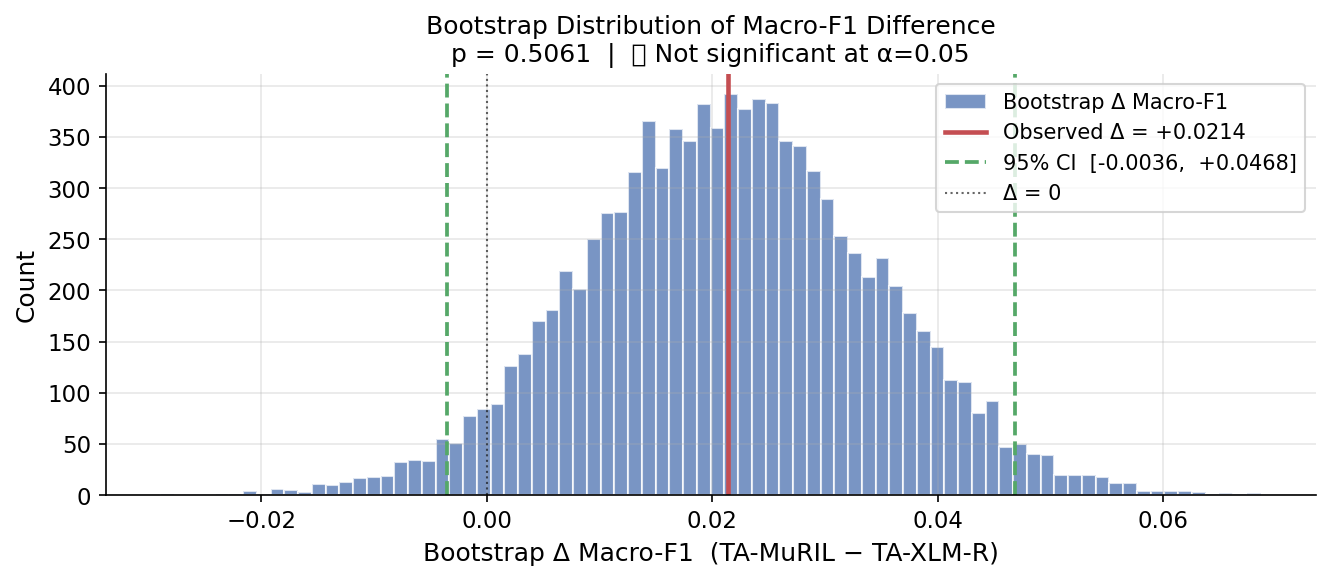

Saved → /kaggle/working/bootstrap_f1_distribution.png


In [8]:
# ── Bootstrap Distribution Plot ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(9, 4))

deltas    = bs_result["deltas"]
delta_obs = bs_result["delta_obs"]
ci_lo     = bs_result["ci_lo"]
ci_hi     = bs_result["ci_hi"]

ax.hist(deltas, bins=80, color="#4C72B0", alpha=0.75, edgecolor="white",
        label="Bootstrap Δ Macro-F1")
ax.axvline(delta_obs, color="#C44E52", linewidth=2.2,
           label=f"Observed Δ = {delta_obs:+.4f}")
ax.axvline(ci_lo, color="#55A868", linewidth=1.8, linestyle="--",
           label=f"95% CI  [{ci_lo:+.4f},  {ci_hi:+.4f}]")
ax.axvline(ci_hi, color="#55A868", linewidth=1.8, linestyle="--")
ax.axvline(0, color="black", linewidth=1.0, linestyle=":", alpha=0.6, label="Δ = 0")

ax.set_xlabel("Bootstrap Δ Macro-F1  (TA-MuRIL − TA-XLM-R)", fontsize=12)
ax.set_ylabel("Count", fontsize=12)
ax.set_title("Bootstrap Distribution of Macro-F1 Difference\n"
             f"p = {bs_result['p_value']:.4f}  |  "
             f"{'✅ Significant' if bs_result['significant'] else '❌ Not significant'} at α=0.05",
             fontsize=12)
ax.legend(fontsize=10)
fig.tight_layout()
plt.savefig("/kaggle/working/bootstrap_f1_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → /kaggle/working/bootstrap_f1_distribution.png")

## 6. Per-class F1 Comparison

In [9]:
# ── Per-class F1 breakdown ────────────────────────────────────────────────────
print("=" * 58)
print(f"  {'Class':<22}  {'TA-MuRIL':>10}  {'TA-XLM-R':>10}  {'Δ':>6}")
print("-" * 58)

for i, lbl in enumerate(LABEL_NAMES):
    mask     = (y_true == i).astype(int)
    f1_m = f1_score(mask, (y_pred_muril == i).astype(int), average="binary", zero_division=0)
    f1_x = f1_score(mask, (y_pred_xlmr  == i).astype(int), average="binary", zero_division=0)
    arrow = "↑" if f1_m > f1_x else ("↓" if f1_m < f1_x else "=")
    print(f"  {lbl:<22}  {f1_m:>10.4f}  {f1_x:>10.4f}  {f1_m-f1_x:>+5.4f} {arrow}")

print("-" * 58)
mf1_m = f1_score(y_true, y_pred_muril, average="macro", zero_division=0)
mf1_x = f1_score(y_true, y_pred_xlmr,  average="macro", zero_division=0)
print(f"  {'Macro-F1':<22}  {mf1_m:>10.4f}  {mf1_x:>10.4f}  {mf1_m-mf1_x:>+5.4f}")
print("=" * 58)

  Class                     TA-MuRIL    TA-XLM-R       Δ
----------------------------------------------------------
  Literary Appreciation       0.9086      0.8883  +0.0204 ↑
  Analytical Reflection       0.7024      0.6679  +0.0345 ↑
  Constructive Critique       0.5953      0.5731  +0.0222 ↑
  Strong Critique             0.6726      0.6639  +0.0087 ↑
----------------------------------------------------------
  Macro-F1                    0.7197      0.6983  +0.0214


## 7. Full Classification Reports

In [10]:
# ── Full classification reports side by side ──────────────────────────────────
print("\n──────── TA-MuRIL v4 ────────")
print(classification_report(
    y_true, y_pred_muril,
    target_names=LABEL_NAMES, digits=4, zero_division=0
))

print("\n──────── TA-XLM-R v4 ────────")
print(classification_report(
    y_true, y_pred_xlmr,
    target_names=LABEL_NAMES, digits=4, zero_division=0
))


──────── TA-MuRIL v4 ────────
                       precision    recall  f1-score   support

Literary Appreciation     0.9016    0.9157    0.9086      2693
Analytical Reflection     0.7048    0.7000    0.7024       740
Constructive Critique     0.6178    0.5744    0.5953       242
      Strong Critique     0.7379    0.6179    0.6726       123

             accuracy                         0.8423      3798
            macro avg     0.7405    0.7020    0.7197      3798
         weighted avg     0.8399    0.8423    0.8408      3798


──────── TA-XLM-R v4 ────────
                       precision    recall  f1-score   support

Literary Appreciation     0.9146    0.8633    0.8883      2693
Analytical Reflection     0.6167    0.7284    0.6679       740
Constructive Critique     0.5492    0.5992    0.5731       242
      Strong Critique     0.6780    0.6504    0.6639       123

             accuracy                         0.8133      3798
            macro avg     0.6896    0.7103    0.698

## 8. Paper-Ready Summary Table

Copy this output directly into your Results section.


In [11]:
# ── Paper-ready summary table ─────────────────────────────────────────────────
mc_p  = mc_result["p_value"]
bs_p  = bs_result["p_value"]
both_sig = mc_result["significant"] and bs_result["significant"]

print("\n" + "=" * 70)
print("  TABLE — Statistical Significance  (TA-MuRIL v4 vs TA-XLM-R v4)")
print("=" * 70)
print(f"  {'Test':<35} {'Statistic':>12}  {'p-value':>10}  {'Sig (α=0.05)':>12}")
print("-" * 70)
print(f"  {'McNemar (exact binomial)':<35} "
      f"  {mc_result['statistic']:>10.4f}  {mc_p:>10.4f}  "
      f"{'✅ Yes' if mc_result['significant'] else '❌ No':>12}")
print(f"  {'Bootstrap Macro-F1 (n=10,000)':<35} "
      f"  {'—':>10}  {bs_p:>10.4f}  "
      f"{'✅ Yes' if bs_result['significant'] else '❌ No':>12}")
print("=" * 70)

print()
print("  Bootstrap 95% CI of Δ Macro-F1 : "
      f"[{bs_result['ci_lo']:+.4f},  {bs_result['ci_hi']:+.4f}]")
print(f"  Observed  Δ Macro-F1            :  {bs_result['delta_obs']:+.4f}")
print(f"  McNemar  b (only MuRIL correct) :  {mc_result['b']}")
print(f"  McNemar  c (only XLM-R correct) :  {mc_result['c']}")
print()
if both_sig:
    winner = mc_result["winner"]
    print(f"  ✅ Both tests significant → {winner} is statistically better")
elif mc_result["significant"] or bs_result["significant"]:
    print("  ⚠️  One test significant — report both, discuss in paper")
else:
    print("  ❌ Neither test significant — difference may be due to chance")
print("=" * 70)


  TABLE — Statistical Significance  (TA-MuRIL v4 vs TA-XLM-R v4)
  Test                                   Statistic     p-value  Sig (α=0.05)
----------------------------------------------------------------------
  McNemar (exact binomial)                198.0000      0.0000         ✅ Yes
  Bootstrap Macro-F1 (n=10,000)                  —      0.5061          ❌ No

  Bootstrap 95% CI of Δ Macro-F1 : [-0.0036,  +0.0468]
  Observed  Δ Macro-F1            :  +0.0214
  McNemar  b (only MuRIL correct) :  308
  McNemar  c (only XLM-R correct) :  198

  ⚠️  One test significant — report both, discuss in paper
